# Exploring the Dataset

This notebook introduces the electricity price and household load data we'll use throughout the workshop.

**Data structure:**
- 156 weeks (3 years) of hourly data
- Each week has 168 hours (7 days × 24 hours)
- Arrays are shaped `(156, 168)` for easy episode-based access

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
prices = np.load('../../03_data/prices.npy')
loads = np.load('../../03_data/loads.npy')

print(f"Prices shape: {prices.shape}") # (#weeks, #hours per week)
print(f"Loads shape:  {loads.shape}") # (#weeks, #hours per week)

Prices shape: (156, 168)
Loads shape:  (156, 168)


## Accessing Data by Week

The data is organized so each episode (week) is one row:

In [2]:
# Get week 10
week_10_prices = prices[10]  # Shape: (168,)
week_10_loads = loads[10]    # Shape: (168,)

# Get hour 50 of week 10
price_at_hour_50 = prices[10, 50]
load_at_hour_50 = loads[10, 50]

print(f"Week 10, Hour 50:")
print(f"  Price: {price_at_hour_50:.3f} €/kWh")
print(f"  Load:  {load_at_hour_50:.3f} kWh")

Week 10, Hour 50:
  Price: 0.095 €/kWh
  Load:  0.334 kWh


## One Week of Data

Each row in the arrays represents one week. Let's visualize week 0.

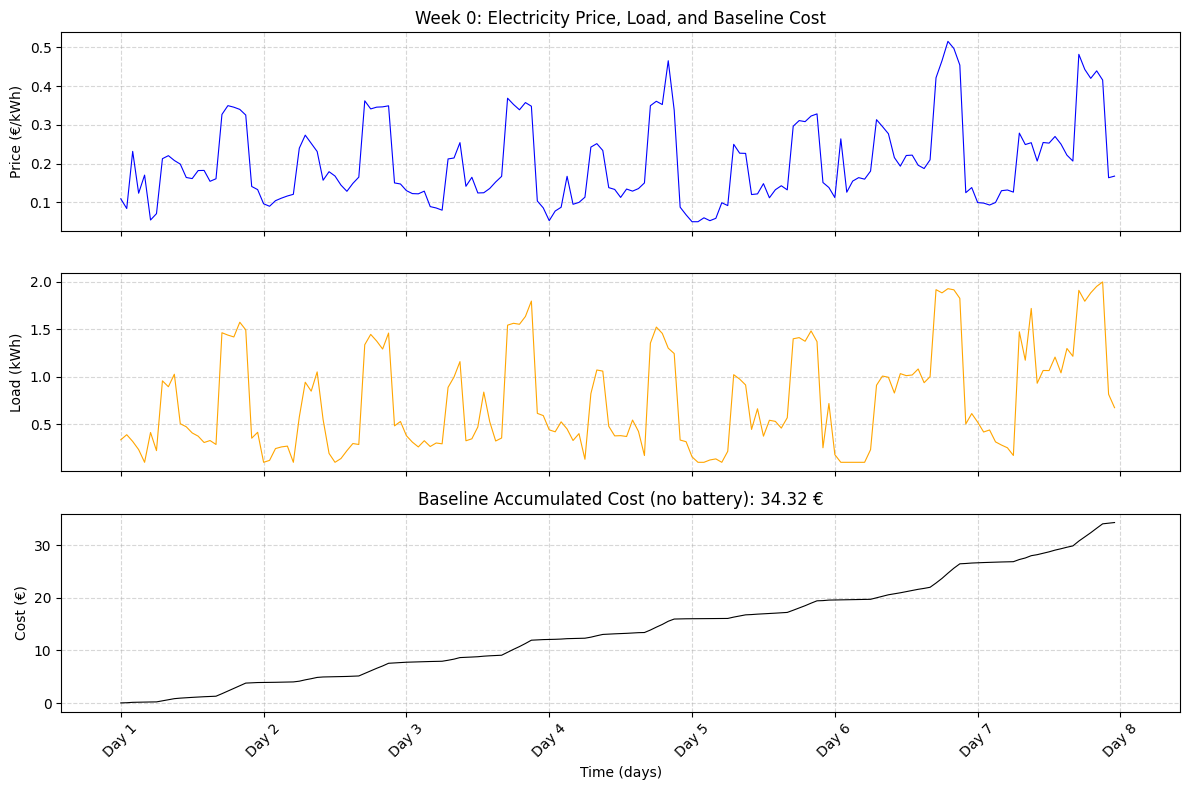

In [3]:
# Plot data for week 0
week_idx = 0
hours_to_plot = len(prices[week_idx])
hours = np.arange(hours_to_plot)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Plot price, load, and accumulated cost
# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Price plot
ax1.plot(hours, prices[week_idx], 'b-', linewidth=0.8)
ax1.set_ylabel('Price (€/kWh)')
ax1.set_title(f'Week {week_idx}: Electricity Price, Load, and Baseline Cost')
ax1.grid(alpha=0.5, linestyle='--')

# Load plot
ax2.plot(hours, loads[week_idx], color='orange', linewidth=0.8)
ax2.set_ylabel('Load (kWh)')
ax2.grid(alpha=0.5, linestyle='--')

# Accumulated cost for this week
hourly_cost = prices[week_idx] * loads[week_idx]
accumulated_cost = np.cumsum(hourly_cost)
ax3.plot(hours, accumulated_cost, 'black', linewidth=0.8)
ax3.set_ylabel('Cost (€)')
ax3.set_title(f'Baseline Accumulated Cost (no battery): {accumulated_cost[-1]:.2f} €')
ax3.set_xlabel('Hour of week')
ax3.grid(alpha=0.5, linestyle='--')

# Day boundary markers. Set x-ticks to represent days
days = np.arange(0, hours_to_plot + 1, 24)
day_labels = [f'Day {i//24 + 1}' for i in days]
plt.xticks(days, day_labels, rotation=45)
ax3.set_xlabel('Time (days)')
ax3.set_xlim(-10, hours_to_plot + 10)

plt.tight_layout()
plt.show()

## Data Summary

Let's plot the data continuously over multiple weeks (3 weeks) and print summary statistics. In total we have 3 years of data, but for visualization, we'll focus on the first 3 weeks.

Total time steps in dataset: 26208 hours, which are 156 weeks, or 3 years. 

Electricity Prices (€/kWh):
  Min:  0.050
  Max:  0.608
  Mean: 0.205

Household Load (kWh):
  Min:  0.100
  Max:  2.632
  Mean: 0.802


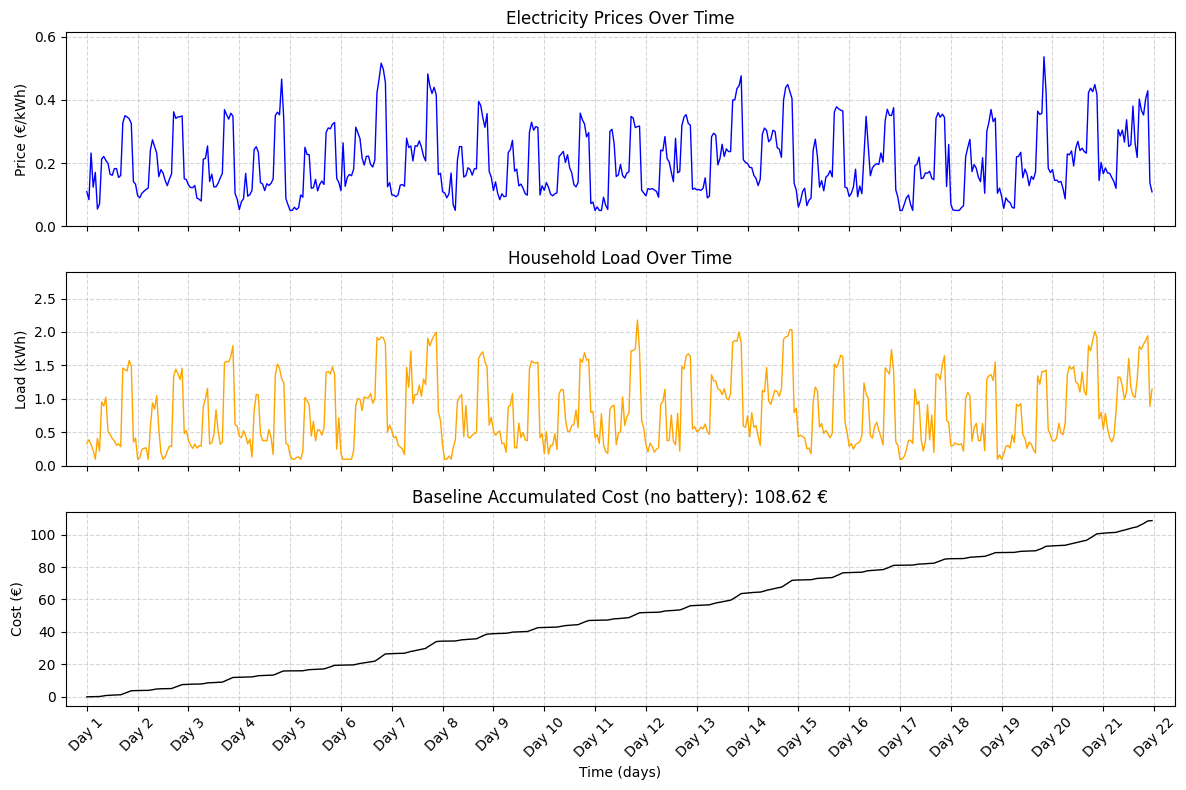

In [4]:
# print out the total amout of time steps in the dataset
total_hours = prices.shape[0] * prices.shape[1]
print(f"Total time steps in dataset: {total_hours} hours, which are {prices.shape[0]} weeks, or {total_hours / 24 / 365:.0f} years. \n")

# Plot the data continuously over multiple weeks (3 weeks)
weeks_to_plot = 3
hours_to_plot = weeks_to_plot * 7 * 24  # 3 weeks * 7 days * 24 hours/day
prices_flat = prices.flatten()[:hours_to_plot] # Flatten and take first 'time_to_plot' hours. 
loads_flat = loads.flatten()[:hours_to_plot] # Flatten and take first 'time_to_plot' hours. 

# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Plot electricity prices
ax1.plot(prices_flat, color='blue', linewidth=1)
ax1.set_ylabel('Price (€/kWh)')
ax1.set_title('Electricity Prices Over Time')
ax1.set_ylim(0, prices.max() * 1.01)
ax1.grid(alpha=0.5, linestyle='--')

# Plot household loads
ax2.plot(loads_flat, color='orange', linewidth=1)
ax2.set_ylabel('Load (kWh)')
ax2.set_title('Household Load Over Time')
ax2.set_ylim(0, loads.max() * 1.1)
ax2.grid(alpha=0.5, linestyle='--')

# Plot accumulated baseline cost (no battery). This is the cost if all load is purchased directly from the grid.
hourly_cost = prices_flat * loads_flat
accumulated_cost = np.cumsum(hourly_cost)
ax3.plot(accumulated_cost, color='black', linewidth=1)
ax3.set_ylabel('Cost (€)')
ax3.set_title(f'Baseline Accumulated Cost (no battery): {accumulated_cost[-1]:.2f} €')
ax3.grid(alpha=0.5, linestyle='--')

# Set x-ticks to represent days
days = np.arange(0, hours_to_plot + 1, 24)
day_labels = [f'Day {i//24 + 1}' for i in days]
plt.xticks(days, day_labels, rotation=45)
ax3.set_xlabel('Time (days)')
ax3.set_xlim(-10, hours_to_plot + 10)

# Print summary statistics
print("Electricity Prices (€/kWh):")
print(f"  Min:  {prices.min():.3f}")
print(f"  Max:  {prices.max():.3f}")
print(f"  Mean: {prices.mean():.3f}")
print("\nHousehold Load (kWh):")
print(f"  Min:  {loads.min():.3f}")
print(f"  Max:  {loads.max():.3f}")
print(f"  Mean: {loads.mean():.3f}")

plt.tight_layout()
plt.show()

## Key Patterns

Notice the patterns in the data:

- **Prices** are low at night, high in the evening
- **Load** follows daily routines: low at night, peaks in morning and evening
- **Weekends** (Sat/Sun) have different patterns than weekdays

These patterns create opportunities for a "smart" battery to **buy cheap, and use stored energy when prices are high**.